In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
df=pd.read_csv("Life Expectancy Data.csv")
X=df.drop('Life expectancy ',axis=1)
y=df["Life expectancy "]
X=pd.get_dummies(X,columns=['Country','Status'])
y=y.fillna(0)

In [19]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)
clf=RandomForestRegressor(n_estimators=100,random_state=42)
clf.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# Method1
# Calculate Gini Importance
# Gini importance is derived from the Random Forest algorithm’s internal structure.
# It measures how much each feature contributes to reducing impurity in decision trees.

In [24]:
feature_importance=clf.feature_importances_
feature_importance_df=pd.DataFrame({
    'Features':X.columns,
    'Gini Importance':feature_importance
}).sort_values('Gini Importance', ascending=False)
feature_importance_df

,Features,Gini Importance
12,HIV/AIDS,4.317590e-01
1,Adult Mortality,2.962921e-01
17,Income composition of resources,1.576075e-01
7,BMI,2.761245e-02
8,under-five deaths,1.307646e-02
...,...,...
136,Country_Nauru,9.866676e-17
161,Country_Saint Kitts and Nevis,2.007488e-17
68,Country_Dominica,0.000000e+00
147,Country_Palau,0.000000e+00


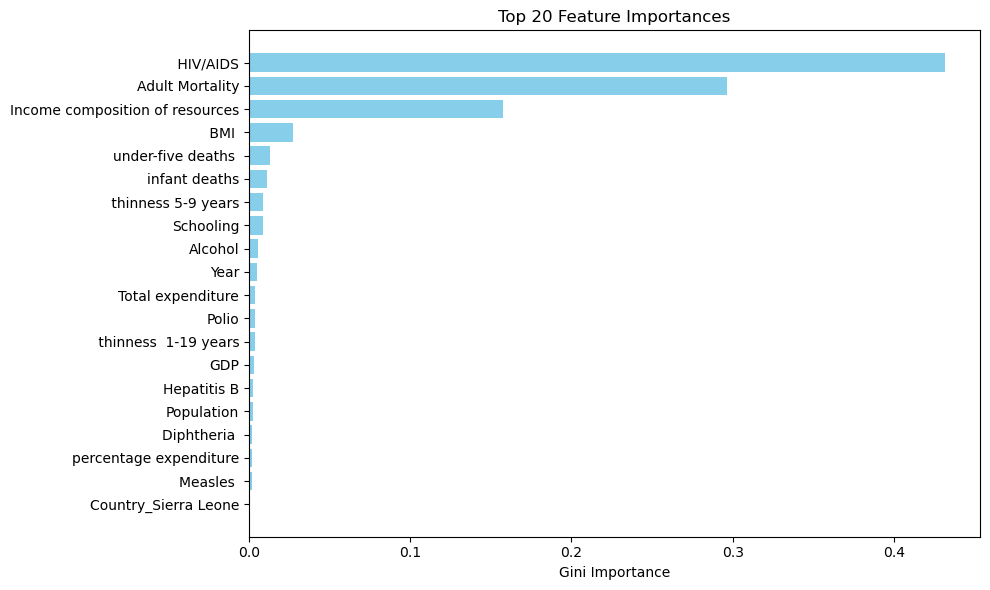

In [26]:
top20 = feature_importance_df.head(20)

plt.figure(figsize=(10,6))
plt.barh(top20['Features'], top20['Gini Importance'], color='skyblue')
plt.xlabel('Gini Importance')
plt.title('Top 20 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [30]:
# Method 2: Mean Decrease Accuracy (MDA)
# Mean Decrease Accuracy (MDA) measures the average reduction in model accuracy across all out-of-bag cross-validated predictions when a particular feature undergoes permutation after training but before making predictions.
# MDA measures how much accuracy drops when each feature is randomly shuffled.
# A larger drop in accuracy means the feature is more important.
from sklearn.metrics import r2_score
pred=clf.predict(X_test)
print(r2_score(y_test,pred))

0.9643453891357066


In [32]:
X1=X[feature_importance_df['Features'].head(20)]

In [38]:
X1_train,X1_test,y_train,y_test=train_test_split(X1,y,test_size=0.2)
clf=RandomForestRegressor(n_estimators=100,random_state=42)
clf.fit(X1_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [39]:
pred1=clf.predict(X1_test)
print(r2_score(y_test,pred1))

0.9627313568226858


In [47]:
# Method 2: Mean Decrease Accuracy (MDA), also called Permutation Feature Importance.
# Mean Decrease Accuracy (MDA) measures the average reduction in model accuracy across all out-of-bag cross-validated predictions when a particular feature undergoes permutation after training but before making predictions.
# MDA measures how much accuracy drops when each feature is randomly shuffled.
# A larger drop in accuracy means the feature is more important.
np.random.seed(42)
importance=[]
intial_accuracy=r2_score(y_test,clf.predict(X_test))
for i in range(X_test.shape[1]):
    X_test_copy=X_test.copy()
    X_test_copy.iloc[:, i] = np.random.permutation(X_test_copy.iloc[:, i])
    next_accuracy=r2_score(y_test,clf.predict(X_test_copy))
    importance.append(intial_accuracy-next_accuracy)
accuracy_df = pd.DataFrame({'Feature': X_test.columns, 'Decrease in Accuracy': importance}).sort_values(
    'Decrease in Accuracy', ascending=False)
print(accuracy_df)

                            Feature  Decrease in Accuracy
4                under-five deaths               0.064541
5                     infant deaths              0.012087
19             Country_Sierra Leone              0.001000
13                              GDP              0.000546
18                         Measles              -0.001922
17           percentage expenditure             -0.004394
8                           Alcohol             -0.006115
15                       Population             -0.006491
16                      Diphtheria              -0.011083
14                      Hepatitis B             -0.014398
10                Total expenditure             -0.015190
12             thinness  1-19 years             -0.017098
11                            Polio             -0.028422
9                              Year             -0.036653
6                thinness 5-9 years             -0.047392
7                         Schooling             -0.048619
3             

In [48]:
# Method 3: Permutation Feature Importance
# Uses a statistical approach to measure importance by shuffling each feature.
# More robust than Gini importance as it does not depend on model internals.
# The permutation_importance() function from scikit-learn automates this process.
from sklearn.inspection import permutation_importance

result = permutation_importance(
    clf,
    X_test,
    y_test,
    scoring="r2",
    n_repeats=10,
    random_state=42
)

accuracy_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Decrease in R²": result.importances_mean
}).sort_values("Decrease in R²", ascending=False)

print(accuracy_df)

                            Feature  Decrease in R²
4                under-five deaths         0.053287
5                     infant deaths        0.006092
13                              GDP        0.001909
19             Country_Sierra Leone        0.001204
18                         Measles        -0.003489
17           percentage expenditure       -0.003597
8                           Alcohol       -0.004329
15                       Population       -0.005297
10                Total expenditure       -0.012822
16                      Diphtheria        -0.013472
12             thinness  1-19 years       -0.015450
14                      Hepatitis B       -0.015538
9                              Year       -0.025432
11                            Polio       -0.028995
6                thinness 5-9 years       -0.048043
3                              BMI        -0.049902
7                         Schooling       -0.059807
0                          HIV/AIDS       -0.251272
1           

In [ ]:
# Method 4: SHAP values
# SHAP (SHapley Additive exPlanations) 